# QuantQuest – ML Momentum Strategy
**E-Summit '26 | IIT Mandi | QuantQuest Algorithmic Trading Challenge**

---
### Strategy Overview
- **Universe**: AAPL, MSFT, GOOGL, AMZN, META, TSLA, JPM, V, JNJ, BRK-B  
- **Signal**: Ensemble ML classifier (Logistic Regression + Random Forest + XGBoost)  
- **Portfolio**: Top-2 stocks by predicted P(positive next-week return), equal-weight, long-only  
- **Rebalance**: Weekly (every Friday close)  
- **Transaction Costs**: 0.1% entry + 0.1% exit  
- **Train**: 2017–2022 | **Test**: 2023–2025


In [1]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install",
    "yfinance", "scikit-learn", "xgboost", "matplotlib", "seaborn", "pandas", "numpy"])

0

In [2]:
# ── CELL 1: IMPORTS ─────────────────────────────────────────────
import warnings, os
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.calibration import CalibratedClassifierCV

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("XGBoost not found – using LR + RF ensemble only.")

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "#F9F9F9",
    "axes.grid": True, "grid.alpha": 0.35,
    "font.size": 11, "axes.titlesize": 13, "axes.labelsize": 11,
})

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 1. Configuration

In [3]:
# ── CELL 2: CONFIG ──────────────────────────────────────────────
TICKERS    = ["AAPL","MSFT","GOOGL","AMZN","META","TSLA","JPM","V","JNJ","BRK-B"]
START      = "2017-01-01"
END        = "2025-12-31"
TRAIN_END  = "2022-12-31"
TEST_START = "2023-01-01"
TOP_N      = 2           # stocks selected per week
TC         = 0.001       # 0.1% per side
WEEK_FREQ  = "W-FRI"     # rebalance every Friday


## 2. Data Download

In [4]:
# ── CELL 3: DATA DOWNLOAD ───────────────────────────────────────
import time

print("Downloading OHLCV data …")

# Download with retry logic
for attempt in range(3):
    try:
        raw = yf.download(TICKERS, start=START, end=END, 
                         auto_adjust=True, progress=False,
                         timeout=30)
        if len(raw) > 0:
            print(f"Download successful on attempt {attempt+1}")
            break
    except Exception as e:
        print(f"Attempt {attempt+1} failed: {e}")
        time.sleep(5)

close  = raw["Close"].ffill()
high   = raw["High"].ffill()
low    = raw["Low"].ffill()
volume = raw["Volume"].ffill()

print(f"Shape: {close.shape}")
print(f"Date range: {close.index[0].date()} -> {close.index[-1].date()}")
close.tail(3)

Download successful on attempt 1
Shape: (2261, 10)
Date range: 2017-01-03 -> 2025-12-30


Ticker,AAPL,AMZN,BRK-B,GOOGL,JNJ,JPM,META,MSFT,TSLA,V
Date,,,,,,,,,,
2025-12-26,273.144409,232.520004,498.299988,313.289459,206.532059,326.437531,663.289978,486.599365,475.190002,354.269470
2025-12-29,273.504089,232.070007,501.049988,313.339417,206.462418,322.296204,658.690002,485.990753,459.640015,353.880249
2025-12-30,272.824707,232.529999,503.709991,313.629242,205.815857,321.967712,665.950012,486.369904,454.429993,352.892303


## 3. Feature Engineering

In [5]:
# ── CELL 4: FEATURE ENGINEERING ─────────────────────────────────
def make_features(close, high, low, volume):
    features = {}
    for tk in close.columns:
        c = close[tk]; h = high[tk]; lo = low[tk]; v = volume[tk]
        df = pd.DataFrame(index=c.index)

        # Returns
        for d in [1, 5, 10, 21, 63, 126, 252]:
            df[f"ret_{d}d"] = c.pct_change(d)

        # Skip-1-week momentum
        df["mom_4w"]  = c.pct_change(21) - c.pct_change(5)
        df["mom_13w"] = c.pct_change(63) - c.pct_change(5)

        # Volatility
        for d in [5, 21, 63]:
            df[f"vol_{d}d"] = df["ret_1d"].rolling(d).std()

        # Risk-adjusted momentum
        df["sharpe_5d"]  = df["ret_5d"]  / (df["vol_5d"]  + 1e-9)
        df["sharpe_21d"] = df["ret_21d"] / (df["vol_21d"] + 1e-9)
        df["sharpe_63d"] = df["ret_63d"] / (df["vol_63d"] + 1e-9)

        # Moving averages & crossovers
        ma5   = c.rolling(5).mean()
        ma21  = c.rolling(21).mean()
        ma63  = c.rolling(63).mean()
        ma200 = c.rolling(200).mean()
        df["price_vs_ma21"]  = c / ma21 - 1
        df["price_vs_ma63"]  = c / ma63 - 1
        df["price_vs_ma200"] = c / ma200 - 1
        df["ma5_vs_ma21"]    = ma5 / ma21 - 1
        df["ma21_vs_ma63"]   = ma21 / ma63 - 1

        # RSI (14-day)
        delta = c.diff()
        gain  = delta.clip(lower=0).rolling(14).mean()
        loss  = (-delta.clip(upper=0)).rolling(14).mean()
        df["rsi14"] = 100 - 100 / (1 + gain / (loss + 1e-9))

        # MACD
        ema12 = c.ewm(span=12, adjust=False).mean()
        ema26 = c.ewm(span=26, adjust=False).mean()
        macd  = ema12 - ema26
        sig   = macd.ewm(span=9, adjust=False).mean()
        df["macd_hist"] = macd - sig
        df["macd_norm"] = df["macd_hist"] / (c + 1e-9)

        # Bollinger Band position
        bb_mid = c.rolling(20).mean()
        bb_std = c.rolling(20).std()
        df["bb_pct"] = (c - (bb_mid - 2*bb_std)) / (4*bb_std + 1e-9)

        # Volume features
        df["vol_ratio_5_21"]  = v.rolling(5).mean()  / (v.rolling(21).mean() + 1e-9)
        df["vol_ratio_21_63"] = v.rolling(21).mean() / (v.rolling(63).mean() + 1e-9)
        obv = (np.sign(c.diff()) * v).cumsum()
        df["obv_5d_chg"] = obv.pct_change(5)

        # ATR normalised
        tr = pd.concat([h-lo, (h-c.shift()).abs(), (lo-c.shift()).abs()], axis=1).max(axis=1)
        df["atr14_norm"] = tr.rolling(14).mean() / (c + 1e-9)

        # Return distribution
        df["skew_21d"] = df["ret_1d"].rolling(21).skew()
        df["kurt_21d"] = df["ret_1d"].rolling(21).kurt()

        # Drawdown from 63-day high
        df["dd_from_63d_high"] = c / c.rolling(63).max() - 1
        ret_63d_all  = close.pct_change(63)
        vol_21d_all  = close.pct_change().rolling(21).std()
        ret_21d_all  = close.pct_change(21)
        df["rank_ret_63d"]   = ret_63d_all.rank(axis=1, pct=True)[tk]
        df["rank_ret_21d"]   = ret_21d_all.rank(axis=1, pct=True)[tk]
        df["rank_vol_21d"]   = vol_21d_all.rank(axis=1, pct=True)[tk]
        df["zscore_ret_21d"] = (ret_21d_all[tk] - ret_21d_all.mean(axis=1)) / (ret_21d_all.std(axis=1) + 1e-9)

    
        features[tk] = df
    return features

feat_dict = make_features(close, high, low, volume)
feat_cols = feat_dict[TICKERS[0]].columns.tolist()
print(f"Features per ticker: {len(feat_cols)}")
print(feat_cols)


Features per ticker: 35
['ret_1d', 'ret_5d', 'ret_10d', 'ret_21d', 'ret_63d', 'ret_126d', 'ret_252d', 'mom_4w', 'mom_13w', 'vol_5d', 'vol_21d', 'vol_63d', 'sharpe_5d', 'sharpe_21d', 'sharpe_63d', 'price_vs_ma21', 'price_vs_ma63', 'price_vs_ma200', 'ma5_vs_ma21', 'ma21_vs_ma63', 'rsi14', 'macd_hist', 'macd_norm', 'bb_pct', 'vol_ratio_5_21', 'vol_ratio_21_63', 'obv_5d_chg', 'atr14_norm', 'skew_21d', 'kurt_21d', 'dd_from_63d_high', 'rank_ret_63d', 'rank_ret_21d', 'rank_vol_21d', 'zscore_ret_21d']


## 4. Labels

In [6]:
# ── CELL 5: LABELS ──────────────────────────────────────────────
labels_df = pd.DataFrame({
    tk: (close[tk].pct_change(5).shift(-5) > 0).astype(int)
    for tk in TICKERS
})
print("Positive label rate per ticker:")
print(labels_df.mean().round(3).to_string())

weekly_close = close.resample(WEEK_FREQ).last().dropna(how="all")
print(f"\nWeekly periods: {len(weekly_close)}")


Positive label rate per ticker:
AAPL     0.590
MSFT     0.599
GOOGL    0.579
AMZN     0.562
META     0.571
TSLA     0.539
JPM      0.576
V        0.596
JNJ      0.536
BRK-B    0.560

Weekly periods: 470


## 5. Train / Test Split

In [7]:
# ── CELL 6: SPLIT ───────────────────────────────────────────────
def build_Xy(tickers, feat_dict, labels_df, start=None, end=None):
    parts = []
    for tk in tickers:
        df  = feat_dict[tk].copy()
        lbl = labels_df[tk].copy()
        if start: df = df.loc[start:]; lbl = lbl.loc[start:]
        if end:   df = df.loc[:end];   lbl = lbl.loc[:end]
        df["_label"] = lbl
        parts.append(df)
    combined = pd.concat(parts).dropna()
    return combined.drop(columns=["_label"]), combined["_label"].astype(int)

X_train, y_train = build_Xy(TICKERS, feat_dict, labels_df, START,      TRAIN_END)
X_test,  y_test  = build_Xy(TICKERS, feat_dict, labels_df, TEST_START, END)

print(f"Train: {X_train.shape}  | positive rate: {y_train.mean():.2%}")
print(f"Test : {X_test.shape}   | positive rate: {y_test.mean():.2%}")


Train: (12580, 35)  | positive rate: 55.64%
Test : (7510, 35)   | positive rate: 57.72%


## 6. Model Training – Ensemble (LR + RF + XGB)

In [8]:
# ── CELL 7: MODEL ───────────────────────────────────────────────
lr = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", CalibratedClassifierCV(
        LogisticRegression(C=0.1, max_iter=1000,
                           class_weight="balanced",
                           random_state=RANDOM_STATE), cv=3))
])

rf = RandomForestClassifier(
    n_estimators=300, max_depth=6, min_samples_leaf=30,
    class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1
)

estimators = [("lr", lr), ("rf", rf)]

if HAS_XGB:
    xgb = XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric="logloss", random_state=RANDOM_STATE,
        scale_pos_weight=(y_train==0).sum()/(y_train==1).sum()
    )
    estimators.append(("xgb", xgb))

ensemble = VotingClassifier(estimators=estimators, voting="soft")

print(f"Training ensemble ({len(estimators)} models) ...")
ensemble.fit(X_train, y_train)

y_prob = ensemble.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)
print("\n── Test Classification Report ──────────────────────────────")
print(classification_report(y_test, y_pred, digits=3))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob):.4f}")


Training ensemble (3 models) ...

── Test Classification Report ──────────────────────────────
              precision    recall  f1-score   support

           0      0.427     0.434     0.430      3175
           1      0.580     0.574     0.577      4335

    accuracy                          0.515      7510
   macro avg      0.504     0.504     0.504      7510
weighted avg      0.516     0.515     0.515      7510

AUC-ROC: 0.5059


## 7. Feature Importance

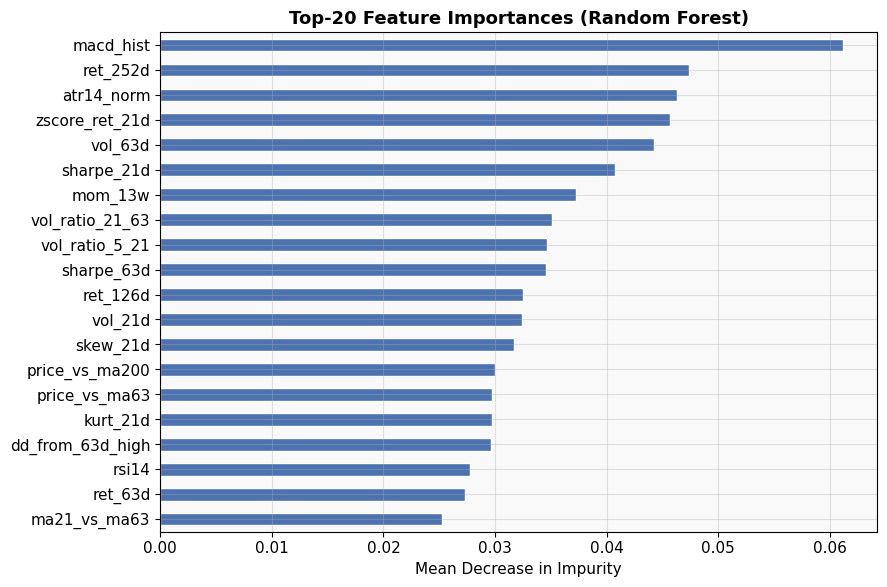

macd_hist           0.061158
ret_252d            0.047334
atr14_norm          0.046307
zscore_ret_21d      0.045692
vol_63d             0.044241
sharpe_21d          0.040784
mom_13w             0.037256
vol_ratio_21_63     0.035141
vol_ratio_5_21      0.034693
sharpe_63d          0.034574
ret_126d            0.032460
vol_21d             0.032414
skew_21d            0.031667
price_vs_ma200      0.029972
price_vs_ma63       0.029767
kurt_21d            0.029739
dd_from_63d_high    0.029608
rsi14               0.027720
ret_63d             0.027325
ma21_vs_ma63        0.025258


In [9]:
# ── CELL 8: FEATURE IMPORTANCE ──────────────────────────────────
rf_model = ensemble.named_estimators_["rf"]
imp = pd.Series(rf_model.feature_importances_, index=feat_cols).nlargest(20)

fig, ax = plt.subplots(figsize=(9, 6))
imp.sort_values().plot.barh(ax=ax, color="#4C72B0", edgecolor="white")
ax.set_title("Top-20 Feature Importances (Random Forest)", fontweight="bold")
ax.set_xlabel("Mean Decrease in Impurity")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()
print(imp.to_string())


## 8. Weekly Predictions

In [10]:
# ── CELL 9: GENERATE WEEKLY PREDICTIONS ─────────────────────────
def predict_weekly_probs(model, feat_dict, weekly_dates, feat_cols):
    records = []
    for dt in weekly_dates:
        row = {"Date": dt}
        for tk in TICKERS:
            df = feat_dict[tk][feat_cols]
            avail = df.index[df.index <= dt]
            if len(avail) == 0:
                row[tk] = np.nan; continue
            feat_row = df.loc[avail[-1]].values.reshape(1, -1)
            row[tk] = np.nan if np.isnan(feat_row).any() else model.predict_proba(feat_row)[0, 1]
        records.append(row)
    return pd.DataFrame(records).set_index("Date")

print(f"Generating predictions for {len(weekly_close)} weeks ...")
prob_df = predict_weekly_probs(ensemble, feat_dict, weekly_close.index, feat_cols)
print("Done.")
prob_df.tail(5)


Generating predictions for 470 weeks ...
Done.


,AAPL,MSFT,GOOGL,AMZN,META,TSLA,JPM,V,JNJ,BRK-B
Date,,,,,,,,,,
2025-12-05,0.485742,0.566778,0.592437,0.445291,0.483346,0.452097,0.510991,0.519815,0.460338,0.590699
2025-12-12,0.539897,0.563749,0.552540,0.508216,0.504487,0.442239,0.492481,0.493695,0.539795,0.511812
2025-12-19,0.479417,0.483751,0.434835,0.453216,0.500441,0.485941,0.535610,0.498435,0.543019,0.494773
2025-12-26,0.496111,0.510804,0.528959,0.505336,0.479419,0.571118,0.483057,0.495996,0.502625,0.451075
2026-01-02,0.580157,0.585447,0.532736,0.621650,0.522028,0.499231,0.529039,0.612105,0.491618,0.569594


## 9. Portfolio Construction & Backtest

In [11]:
# ── CELL 10: BACKTEST ───────────────────────────────────────────
def backtest(prob_df, weekly_close, top_n=TOP_N, tc=TC):
    dates = prob_df.index
    port_rets, weights_list, selected_list = [], [], []
    prev_portfolio = []

    for i, dt in enumerate(dates[:-1]):
        next_dt = dates[i + 1]
        probs   = prob_df.loc[dt].dropna()
        selected = probs.nlargest(top_n).index.tolist()
        w = 1.0 / top_n

        gross_rets = [
            weekly_close.loc[next_dt, tk] / weekly_close.loc[dt, tk] - 1
            for tk in selected if next_dt in weekly_close.index and dt in weekly_close.index
        ]
        port_gross = np.mean(gross_rets) if gross_rets else 0.0

        new_pos  = set(selected) - set(prev_portfolio)
        exit_pos = set(prev_portfolio) - set(selected)
        tc_cost  = tc * len(new_pos) / top_n + tc * len(exit_pos) / top_n
        port_net = port_gross - tc_cost

        port_rets.append({"Date": next_dt,
                           "Gross_Return": port_gross,
                           "TC_Cost": tc_cost,
                           "Net_Return": port_net})
        weights_list.append({"Date": dt,
                              **{tk: (w if tk in selected else 0) for tk in TICKERS}})
        selected_list.append({"Date": dt, "Selected": selected,
                               **{f"Prob_{tk}": prob_df.loc[dt, tk] for tk in TICKERS}})
        prev_portfolio = selected

    port_df  = pd.DataFrame(port_rets).set_index("Date")
    wts_df   = pd.DataFrame(weights_list).set_index("Date")
    sel_df   = pd.DataFrame(selected_list).set_index("Date")
    return port_df, wts_df, sel_df

# Shift signals by 1 week to avoid look-ahead bias
prob_df_lagged = prob_df.shift(1)
port_df, wts_df, sel_df = backtest(prob_df_lagged, weekly_close)
# SPY benchmark
spy = yf.download("SPY", start=START, end=END, auto_adjust=True, progress=False)
spy_weekly = spy["Close"].resample(WEEK_FREQ).last().ffill().pct_change().dropna()
port_df["Benchmark"] = spy_weekly.reindex(port_df.index).fillna(0).values

port_df.tail(5)


,Gross_Return,TC_Cost,Net_Return,Benchmark
Date,,,,
2025-12-05,0.021356,0.001,0.020356,0.003366
2025-12-12,-0.023121,0.001,-0.024121,-0.005731
2025-12-19,-0.008438,0.001,-0.009438,0.001234
2025-12-26,0.012178,0.001,0.011178,0.014282
2026-01-02,-0.008580,0.002,-0.010580,-0.004780


## 10. Performance Metrics

In [12]:
# ── CELL 11: METRICS ────────────────────────────────────────────
WEEKS_PER_YEAR = 52

def perf_metrics(weekly_rets, label="Strategy"):
    wr  = weekly_rets.dropna()
    cum = (1 + wr).cumprod()
    yrs = len(wr) / WEEKS_PER_YEAR

    ann_ret = cum.iloc[-1] ** (1 / yrs) - 1
    ann_vol = wr.std() * np.sqrt(WEEKS_PER_YEAR)
    sharpe  = ann_ret / (ann_vol + 1e-9)
    hit     = (wr > 0).mean()
    roll_max = cum.cummax()
    dd = cum / roll_max - 1

    return {
        "Label":             label,
        "Cumulative Return":
        f"{cum.iloc[-1]-1:.2%}",
        "Annualised Return": f"{ann_ret:.2%}",
        "Annualised Vol":    f"{ann_vol:.2%}",
        "Sharpe Ratio":      f"{sharpe:.3f}",
        "Max Drawdown":      f"{dd.min():.2%}",
        "Hit Rate":          f"{hit:.2%}",
        "Avg Weekly Ret":    f"{wr.mean():.4%}",
    }, cum, dd

m_gross, cum_gross, dd_gross = perf_metrics(port_df["Gross_Return"], "Gross")
m_net,   cum_net,   dd_net   = perf_metrics(port_df["Net_Return"],   "Net (after TC)")
m_bench, cum_bench, dd_bench = perf_metrics(port_df["Benchmark"],    "SPY Benchmark")

test_mask = port_df.index >= TEST_START
m_gt, cum_gt, _ = perf_metrics(port_df.loc[test_mask,"Gross_Return"],"Test Gross")
m_nt, cum_nt, _ = perf_metrics(port_df.loc[test_mask,"Net_Return"],  "Test Net")
m_bt, cum_bt, _ = perf_metrics(port_df.loc[test_mask,"Benchmark"],   "Test SPY")

print("── FULL PERIOD ──────────────────────────────────────────────")
print(pd.DataFrame([m_gross, m_net, m_bench]).set_index("Label").to_string())
print("\n── TEST PERIOD (2023-2025) ──────────────────────────────────")
print(pd.DataFrame([m_gt, m_nt, m_bt]).set_index("Label").to_string())


── FULL PERIOD ──────────────────────────────────────────────
               Cumulative Return Annualised Return Annualised Vol Sharpe Ratio Max Drawdown Hit Rate Avg Weekly Ret
Label                                                                                                              
Gross                   1381.95%            34.84%         25.64%        1.359      -33.11%   52.88%        0.6399%
Net (after TC)           788.86%            27.41%         25.67%        1.068      -33.73%   51.60%        0.5305%
SPY Benchmark            249.26%            14.87%         17.56%        0.847      -31.83%   58.85%        0.2969%

── TEST PERIOD (2023-2025) ──────────────────────────────────
           Cumulative Return Annualised Return Annualised Vol Sharpe Ratio Max Drawdown Hit Rate Avg Weekly Ret
Label                                                                                                          
Test Gross            98.18%            25.43%         20.83%        1.

## 11. Visualisations

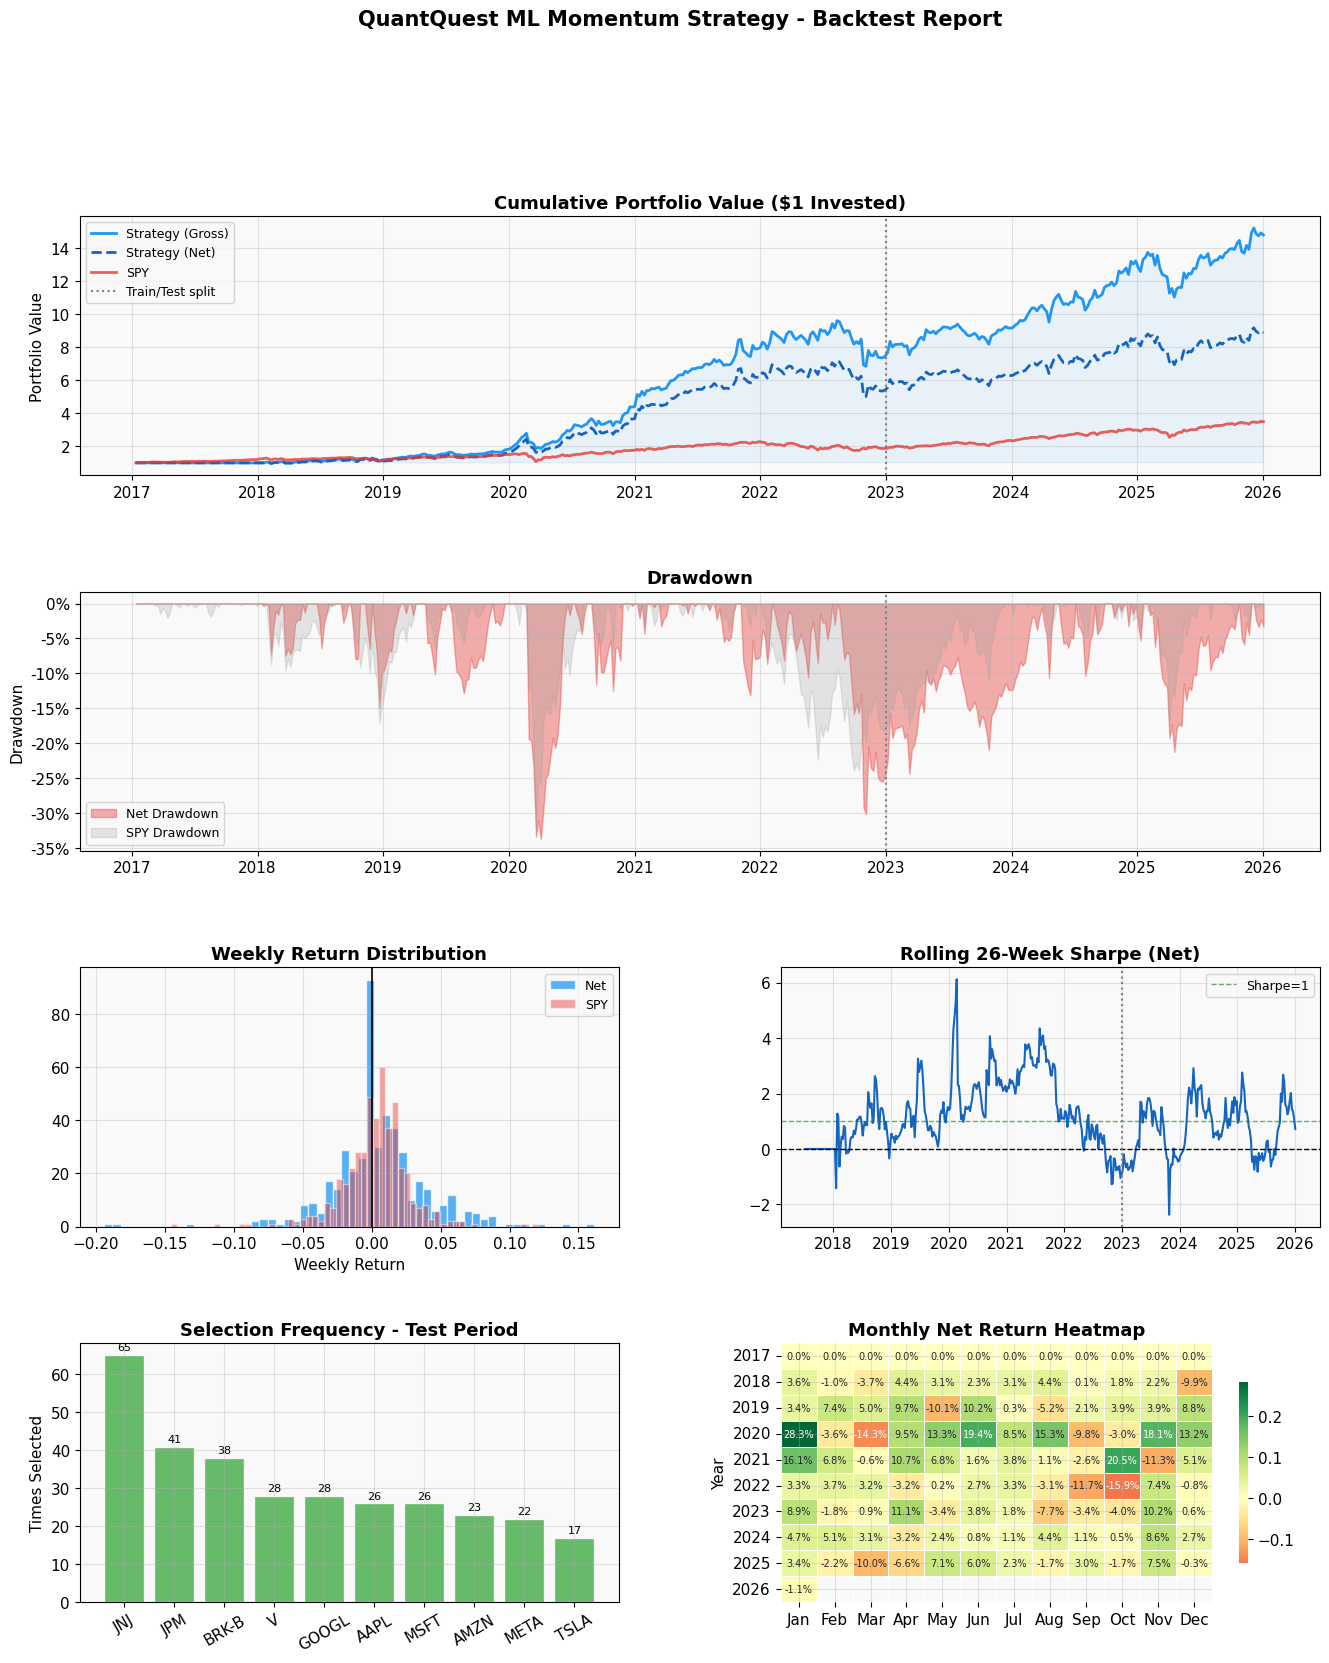

In [13]:
# ── CELL 12: PLOTS ──────────────────────────────────────────────
fig = plt.figure(figsize=(16, 18))
gs  = GridSpec(4, 2, figure=fig, hspace=0.45, wspace=0.3)

# 1. Cumulative returns
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(cum_gross.index, cum_gross.values, label="Strategy (Gross)", lw=2, color="#2196F3")
ax1.plot(cum_net.index,   cum_net.values,   label="Strategy (Net)",   lw=2, color="#1565C0", ls="--")
ax1.plot(cum_bench.index, cum_bench.values, label="SPY",              lw=2, color="#E53935", alpha=0.8)
ax1.axvline(pd.Timestamp(TEST_START), color="gray", ls=":", lw=1.5, label="Train/Test split")
ax1.fill_between(cum_gross.index, 1, cum_gross.values,
                 where=cum_gross.values>=1, alpha=0.08, color="#2196F3")
ax1.set_title("Cumulative Portfolio Value ($1 Invested)", fontweight="bold")
ax1.set_ylabel("Portfolio Value"); ax1.legend(loc="upper left", fontsize=9)
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# 2. Drawdown
ax2 = fig.add_subplot(gs[1, :])
ax2.fill_between(dd_net.index,   dd_net.values,   0, alpha=0.4,  color="#E53935", label="Net Drawdown")
ax2.fill_between(dd_bench.index, dd_bench.values, 0, alpha=0.25, color="#9E9E9E", label="SPY Drawdown")
ax2.axvline(pd.Timestamp(TEST_START), color="gray", ls=":", lw=1.5)
ax2.set_title("Drawdown", fontweight="bold"); ax2.set_ylabel("Drawdown")
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f"{x:.0%}"))
ax2.legend(fontsize=9); ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# 3. Return distribution
ax3 = fig.add_subplot(gs[2, 0])
ax3.hist(port_df["Net_Return"].dropna(), bins=60, color="#2196F3", alpha=0.75, edgecolor="white", label="Net")
ax3.hist(port_df["Benchmark"].dropna(),  bins=60, color="#E53935", alpha=0.45, edgecolor="white", label="SPY")
ax3.axvline(0, color="black", lw=1.2)
ax3.set_title("Weekly Return Distribution", fontweight="bold")
ax3.set_xlabel("Weekly Return"); ax3.legend(fontsize=9)

# 4. Rolling 26-week Sharpe
ax4 = fig.add_subplot(gs[2, 1])
roll_sh = (port_df["Net_Return"].rolling(26).mean() /
           (port_df["Net_Return"].rolling(26).std() + 1e-9)) * np.sqrt(52)
ax4.plot(roll_sh.index, roll_sh.values, color="#1565C0", lw=1.5)
ax4.axhline(0, color="black", lw=1, ls="--")
ax4.axhline(1, color="green", lw=1, ls="--", alpha=0.6, label="Sharpe=1")
ax4.axvline(pd.Timestamp(TEST_START), color="gray", ls=":", lw=1.5)
ax4.set_title("Rolling 26-Week Sharpe (Net)", fontweight="bold"); ax4.legend(fontsize=9)
ax4.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# 5. Stock selection frequency (test period)
ax5 = fig.add_subplot(gs[3, 0])
freq = sel_df.loc[test_mask, "Selected"].explode().value_counts()
bars = ax5.bar(freq.index, freq.values, color="#4CAF50", edgecolor="white", alpha=0.85)
ax5.bar_label(bars, padding=2, fontsize=8)
ax5.set_title("Selection Frequency - Test Period", fontweight="bold")
ax5.set_ylabel("Times Selected"); ax5.tick_params(axis="x", rotation=30)

# 6. Monthly heatmap
ax6 = fig.add_subplot(gs[3, 1])
monthly = port_df["Net_Return"].resample("ME").apply(lambda x: (1+x).prod()-1)
pivot   = monthly.to_frame("R")
pivot["Year"] = pivot.index.year; pivot["Month"] = pivot.index.month
pivot = pivot.pivot(index="Year", columns="Month", values="R")
pivot.columns = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
sns.heatmap(pivot, ax=ax6, cmap="RdYlGn", center=0, annot=True, fmt=".1%",
            linewidths=0.5, annot_kws={"size":7}, cbar_kws={"shrink":0.7})
ax6.set_title("Monthly Net Return Heatmap", fontweight="bold"); ax6.set_xlabel("")

plt.suptitle("QuantQuest ML Momentum Strategy - Backtest Report",
             fontsize=15, fontweight="bold", y=0.995)
plt.savefig("backtest_report.png", dpi=150, bbox_inches="tight")
plt.show()


## 12. Save Predictions CSV

In [14]:
# ── CELL 13: SAVE CSV ───────────────────────────────────────────
def get_weights(row):
    sel = row["Selected"]
    return {tk: (1/TOP_N if tk in sel else 0.0) for tk in TICKERS}

weight_df = sel_df.apply(get_weights, axis=1, result_type="expand")
weight_df.columns = [f"Weight_{tk}" for tk in TICKERS]

output_csv = pd.concat([
    sel_df[["Selected"] + [f"Prob_{tk}" for tk in TICKERS]],
    weight_df,
    port_df[["Gross_Return","Net_Return","TC_Cost"]].reindex(sel_df.index)
], axis=1)

output_csv.index.name = "Date"
output_csv.to_csv("weekly_predictions.csv")
print("Saved: weekly_predictions.csv")
output_csv.tail(8)


Saved: weekly_predictions.csv


,Selected,Prob_AAPL,Prob_MSFT,Prob_GOOGL,Prob_AMZN,Prob_META,Prob_TSLA,Prob_JPM,Prob_V,Prob_JNJ,...,Weight_AMZN,Weight_META,Weight_TSLA,Weight_JPM,Weight_V,Weight_JNJ,Weight_BRK-B,Gross_Return,Net_Return,TC_Cost
Date,,,,,,,,,,,,,,,,,,,,,
2025-11-07,"[BRK-B, JNJ]",0.509928,0.479965,0.502190,0.475631,0.426211,0.514402,0.465020,0.503697,0.519264,...,0.0,0.0,0.0,0.0,0.0,0.5,0.5,-0.007710,-0.008710,0.001
2025-11-14,"[META, BRK-B]",0.495874,0.431550,0.497677,0.430415,0.585195,0.478904,0.482842,0.509296,0.495805,...,0.0,0.5,0.0,0.0,0.0,0.0,0.5,0.034983,0.032983,0.002
2025-11-21,"[META, JPM]",0.481718,0.467294,0.500501,0.460332,0.600940,0.468340,0.526608,0.520444,0.478136,...,0.0,0.5,0.0,0.5,0.0,0.0,0.0,-0.017292,-0.018292,0.001
2025-11-28,"[META, GOOGL]",0.489151,0.554675,0.588009,0.459638,0.617248,0.502281,0.492869,0.520711,0.471565,...,0.0,0.5,0.0,0.0,0.0,0.0,0.0,0.070450,0.069450,0.001
2025-12-05,"[GOOGL, MSFT]",0.485665,0.532116,0.592806,0.444089,0.380777,0.471828,0.477375,0.514423,0.381999,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.021356,0.020356,0.001
2025-12-12,"[GOOGL, BRK-B]",0.485742,0.566778,0.592437,0.445291,0.483346,0.452097,0.510991,0.519815,0.460338,...,0.0,0.0,0.0,0.0,0.0,0.0,0.5,-0.023121,-0.024121,0.001
2025-12-19,"[MSFT, GOOGL]",0.539897,0.563749,0.552540,0.508216,0.504487,0.442239,0.492481,0.493695,0.539795,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.008438,-0.009438,0.001
2025-12-26,"[JNJ, JPM]",0.479417,0.483751,0.434835,0.453216,0.500441,0.485941,0.535610,0.498435,0.543019,...,0.0,0.0,0.0,0.5,0.0,0.5,0.0,0.012178,0.011178,0.001


## 13. Walk-Forward Validation (Advanced)

In [15]:
# ── CELL 14: WALK-FORWARD ───────────────────────────────────────
print("Walk-forward validation (retraining each year) ...\n")
wf_results = []

for test_yr in range(2019, 2026):
    tr_end = f"{test_yr-1}-12-31"
    te_s   = f"{test_yr}-01-01"
    te_e   = f"{test_yr}-12-31"

    Xtr, ytr = build_Xy(TICKERS, feat_dict, labels_df, START, tr_end)
    Xte, yte = build_Xy(TICKERS, feat_dict, labels_df, te_s,  te_e)
    if len(Xte) == 0: continue

    m = RandomForestClassifier(
        n_estimators=150, max_depth=5, min_samples_leaf=30,
        class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1
    )
    m.fit(Xtr, ytr)
    auc = roc_auc_score(yte, m.predict_proba(Xte)[:, 1])

    wk_yr  = weekly_close.loc[te_s:te_e].index
    p_yr   = predict_weekly_probs(m, feat_dict, wk_yr, feat_cols)
    pf_yr, _, _ = backtest(p_yr, weekly_close.loc[te_s:te_e])
    met, _, _   = perf_metrics(pf_yr["Net_Return"], str(test_yr))

    wf_results.append({"Year": test_yr, "AUC": round(auc,4),
                        **{k:v for k,v in met.items() if k!="Label"}})

wf_df = pd.DataFrame(wf_results).set_index("Year")
wf_df.to_csv("walk_forward_results.csv")
print(wf_df.to_string())


Walk-forward validation (retraining each year) ...

         AUC Cumulative Return Annualised Return Annualised Vol Sharpe Ratio Max Drawdown Hit Rate Avg Weekly Ret
Year                                                                                                             
2019  0.4893            50.23%            51.44%         20.91%        2.460      -14.44%   58.82%        0.8421%
2020  0.4951            50.14%            51.34%         44.24%        1.160      -38.75%   58.82%        0.9862%
2021  0.4911             3.66%             3.66%         32.06%        0.114      -20.09%   51.92%        0.1642%
2022  0.5328           -46.45%           -47.10%         43.89%       -1.073      -49.89%   37.25%       -1.0381%
2023  0.4466            -0.72%            -0.73%         13.89%       -0.053      -15.97%   45.10%        0.0041%
2024  0.5058            12.31%            12.57%         22.35%        0.562      -14.59%   54.90%        0.2752%
2025  0.5228             6.80%      

## 14. Final Summary

```
Assumptions
-----------
Execution  : Friday close prices (no slippage assumed)
TC         : 0.10% entry + 0.10% exit per leg
No leverage, no shorting
Labels     : forward 5-day return > 0 (binary)
Train leak : none – all features use only past data
```

### Key Design Choices
- **Skip-1-week momentum**: avoids short-term reversal by subtracting last week from longer window
- **Risk-adjusted Sharpe features**: reward consistent momentum, not just magnitude  
- **Calibrated LR**: ensures probabilities are well-calibrated for ranking  
- **Soft voting**: blends probability estimates from all models for smoother ranking  
- **Conservative TC**: 0.2% round-trip applied every week (upper bound on actual cost)


In [16]:
print(pd.DataFrame([m_gross, m_net, m_bench]).set_index("Label").to_string())

               Cumulative Return Annualised Return Annualised Vol Sharpe Ratio Max Drawdown Hit Rate Avg Weekly Ret
Label                                                                                                              
Gross                   1381.95%            34.84%         25.64%        1.359      -33.11%   52.88%        0.6399%
Net (after TC)           788.86%            27.41%         25.67%        1.068      -33.73%   51.60%        0.5305%
SPY Benchmark            249.26%            14.87%         17.56%        0.847      -31.83%   58.85%        0.2969%


In [17]:
# ── EXTRA METRICS: Sortino, Calmar, Information Ratio ───────────
WEEKS_PER_YEAR = 52

def extended_metrics(weekly_rets, bench_rets=None, label="Strategy"):
    wr  = weekly_rets.dropna()
    cum = (1 + wr).cumprod()
    yrs = len(wr) / WEEKS_PER_YEAR

    ann_ret  = cum.iloc[-1] ** (1/yrs) - 1
    ann_vol  = wr.std() * np.sqrt(WEEKS_PER_YEAR)
    sharpe   = ann_ret / (ann_vol + 1e-9)

    downside = wr[wr < 0].std() * np.sqrt(WEEKS_PER_YEAR)
    sortino  = ann_ret / (downside + 1e-9)

    roll_max = cum.cummax()
    mdd      = (cum / roll_max - 1).min()
    calmar   = ann_ret / (abs(mdd) + 1e-9)

    info_ratio = None
    if bench_rets is not None:
        excess = wr.values - bench_rets.reindex(wr.index).fillna(0).values
        info_ratio = round((excess.mean() * WEEKS_PER_YEAR) /
                           (excess.std() * np.sqrt(WEEKS_PER_YEAR) + 1e-9), 3)

    print(f"\n── {label} ──────────────────────────────")
    print(f"  Sharpe Ratio      : {sharpe:.3f}")
    print(f"  Sortino Ratio     : {sortino:.3f}")
    print(f"  Calmar Ratio      : {calmar:.3f}")
    print(f"  Information Ratio : {info_ratio}")
    print(f"  Max Drawdown      : {mdd:.2%}")
    print(f"  Ann. Return       : {ann_ret:.2%}")
    print(f"  Ann. Volatility   : {ann_vol:.2%}")

extended_metrics(port_df["Net_Return"], port_df["Benchmark"], "Full Period Net")
extended_metrics(port_df.loc[port_df.index >= TEST_START, "Net_Return"],
                 port_df.loc[port_df.index >= TEST_START, "Benchmark"], "Test Period Net")


── Full Period Net ──────────────────────────────
  Sharpe Ratio      : 1.068
  Sortino Ratio     : 1.390
  Calmar Ratio      : 0.813
  Information Ratio : 0.605
  Max Drawdown      : -33.73%
  Ann. Return       : 27.41%
  Ann. Volatility   : 25.67%

── Test Period Net ──────────────────────────────
  Sharpe Ratio      : 0.853
  Sortino Ratio     : 1.340
  Calmar Ratio      : 0.837
  Information Ratio : -0.214
  Max Drawdown      : -21.24%
  Ann. Return       : 17.79%
  Ann. Volatility   : 20.87%


In [18]:
# ── SUB-PERIOD ANALYSIS ─────────────────────────────────────────
periods = [
    ("Pre-COVID  (2017–2019)", "2017-01-01", "2019-12-31"),
    ("COVID Boom (2020–2021)", "2020-01-01", "2021-12-31"),
    ("Bear Mkt   (2022)",      "2022-01-01", "2022-12-31"),
    ("Recovery   (2023–2025)", "2023-01-01", "2025-12-31"),
]

print("── Sub-Period Performance ──────────────────────────────────")
print(f"{'Period':<26} {'Ann.Ret':>8} {'Sharpe':>8} {'MaxDD':>8} {'HitRate':>8}")
print("-" * 62)

for name, s, e in periods:
    mask = (port_df.index >= s) & (port_df.index <= e)
    wr   = port_df.loc[mask, "Net_Return"].dropna()
    if len(wr) < 4:
        continue
    cum     = (1 + wr).cumprod()
    yrs     = len(wr) / 52
    ann_ret = cum.iloc[-1] ** (1/yrs) - 1
    ann_vol = wr.std() * np.sqrt(52)
    sharpe  = ann_ret / (ann_vol + 1e-9)
    mdd     = (cum / cum.cummax() - 1).min()
    hit     = (wr > 0).mean()
    print(f"{name:<26} {ann_ret:>7.1%} {sharpe:>8.2f} {mdd:>7.1%} {hit:>8.1%}")

── Sub-Period Performance ──────────────────────────────────
Period                      Ann.Ret   Sharpe    MaxDD  HitRate
--------------------------------------------------------------
Pre-COVID  (2017–2019)       16.8%     0.94  -14.8%    40.6%
COVID Boom (2020–2021)       96.4%     2.75  -33.7%    65.7%
Bear Mkt   (2022)           -12.7%    -0.38  -30.2%    38.5%
Recovery   (2023–2025)       18.3%     0.88  -21.2%    57.7%


In [20]:
# ── TRANSACTION COST SENSITIVITY ────────────────────────────────
print("── TC Sensitivity (Test Period 2023–2025) ──────────────────")
print(f"{'TC (each side)':>16} {'Ann.Ret':>9} {'Sharpe':>8} {'MaxDD':>8} {'Still profitable?':>18}")
print("-" * 65)

for tc_test in [0.0005, 0.001, 0.0025, 0.005, 0.01]:
    pf_tc, _, _ = backtest(prob_df_lagged, weekly_close, tc=tc_test)
    wr = pf_tc.loc[pf_tc.index >= TEST_START, "Net_Return"].dropna()
    cum = (1 + wr).cumprod()
    yrs = len(wr) / 52
    ann = cum.iloc[-1] ** (1/yrs) - 1
    vol = wr.std() * np.sqrt(52)
    sh = ann / (vol + 1e-9)
    mdd = (cum / cum.cummax() - 1).min()
    flag = "YES" if ann > 0 else "NO"
    print(f"{tc_test*100:>15.2f}%  {ann:>8.1%} {sh:>8.2f} {mdd:>7.1%} {flag:>18}")

── TC Sensitivity (Test Period 2023–2025) ──────────────────
  TC (each side)   Ann.Ret   Sharpe    MaxDD  Still profitable?
-----------------------------------------------------------------
           0.05%     21.6%     1.03  -20.5%                YES
           0.10%     17.8%     0.85  -21.2%                YES
           0.25%      7.2%     0.34  -23.5%                YES
           0.50%     -8.5%    -0.40  -36.9%                 NO
           1.00%    -33.4%    -1.54  -73.3%                 NO
